lets import the data first and see how it goes.

In [1]:
import pandas as pd
  
# makes the passed rows header
data = pd.read_csv("laplace.csv", header =[0])

In [2]:
data

,x,y,u
0,0.00,0.0,0.00
1,0.01,0.0,0.01
2,0.02,0.0,0.02
3,0.03,0.0,0.03
4,0.04,0.0,0.04
...,...,...,...
10196,0.96,1.0,0.96
10197,0.97,1.0,0.97
10198,0.98,1.0,0.98
10199,0.99,1.0,0.99


In [3]:
import numpy as np
converted = np.array(data)

In [4]:
#import sys
#!{sys.executable} -m pip install sklearn

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(converted[:,0:2], converted[:,2], test_size=0.33, random_state=42)

OK, The first section would be a surrogate model, Next Section would be a PINN method

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
# Keras :
from keras import backend as K
import tensorflow as tf
import keras 
from keras.layers import Input, Dense, add, Activation, Reshape , Conv1D, Flatten ,GlobalAveragePooling1D , Lambda, Dropout, concatenate
from keras.models import Model, model_from_json, model_from_yaml
from keras import optimizers 
from keras.callbacks import CSVLogger
from keras.losses import mse
from keras.utils.generic_utils import get_custom_objects

In [8]:
# network input parameters 
n = 2            # number of the input layer neurons 
# convolutional layers parameters
alpha = 14       # number of channels in convolutional layers
ks = 1           # Kernel Size
# optimizer (NAdam) parameters
lr = 0.005       # learning rate
beta_1=0.9       # beta 1
beta_2=0.999     # beta 2
# model fitting parameters
epochs = 5     # epochs
batch_size = 50 # batch size

In [9]:

inputTensor = Input(shape=(n,1))
print(inputTensor)

stack = []

# Part 1: Convolutional layers:
# SubPart 1.1 : Expanding the input to alpha channels and performing convolutions with kernel size of ks
stack.append(Conv1D(alpha, ks, strides=1, input_shape=(1,n,1),padding='same', activation='relu')(inputTensor))
stack.append(Conv1D(alpha, ks, strides=1, padding='same', activation='relu')(add([stack[len(stack)-1],inputTensor])))
stack.append(Conv1D(alpha, ks, strides=1, padding='same', activation='relu')(add([stack[len(stack)-1],inputTensor])))
# SubPart 1.2 : Flattening the results into 1 chanel
stack.append(Conv1D(1, ks, strides=1, padding='same', activation='linear')(add([stack[len(stack)-1],inputTensor])))

# Part 2: Sum-Pooling:
# there is no sumpooling direct layer, so we have to use an global average layer first :
stack.append(GlobalAveragePooling1D(data_format='channels_last')(add([stack[len(stack)-1],inputTensor])))
# and then multiply the result in the total number of elements throughh a lambda layer next:
stack.append(Lambda(lambda x: x * data.shape[1])(stack[len(stack)-1]))

# Part 3: Convolutions equivalent to Dense layers
# SubPart 3.1 : Expanding the input to alpha channels and performing convolution with kernel size 'ks'
stack.append(Conv1D(alpha, ks, strides=1, padding='same', activation='relu')(add([stack[len(stack)-1],inputTensor])))
stack.append(Conv1D(alpha, ks, strides=1, padding='same', activation='relu')(add([stack[len(stack)-1],inputTensor])))
stack.append(Conv1D(alpha, ks, strides=1, padding='same', activation='relu')(add([stack[len(stack)-1],inputTensor])))

# SubPart 3.2 : Flattening alpha channels to 1 channel, so the whole part can be viewd as a dense layer
#shall the kernel size remain 1? or we can use a more dynamic kernel size here
stack.append(Conv1D(1, ks, strides=1, padding='same', activation='linear')(add([stack[len(stack)-1],inputTensor])))

# SubPart 3.3 : Flattening the result so it can be fed into the output layer
stack.append(Flatten()(stack[len(stack)-1])) 

# SubPart 3.4 : The output layer which is a n -> 1 dense layer and will give us one single output 
finalOutput = Dense(1)(stack[len(stack)-1])
print(finalOutput)

# Defining the Actual Model
model = Model(inputTensor,finalOutput)

KerasTensor(type_spec=TensorSpec(shape=(None, 2, 1), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'")
KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), name='dense/BiasAdd:0', description="created by layer 'dense'")


In [10]:

class EarlyStoppingAtMinLoss(tf.keras.callbacks.Callback):
  """Stop training when the loss is at its min, i.e. the loss stops decreasing.

  Arguments:
      patience: Number of epochs to wait after min has been hit. After this
      number of no improvement, training stops.
  """

  def __init__(self, patience=20):
    super(EarlyStoppingAtMinLoss, self).__init__()

    self.patience = patience

    # best_weights to store the weights at which the minimum loss occurs.
    self.best_weights = None

  def on_train_begin(self, logs=None):
    # The number of epoch it has waited when loss is no longer minimum.
    self.wait = 0
    # The epoch the training stops at.
    self.stopped_epoch = 0
    # Initialize the best as infinity.
    self.best = np.Inf

  def on_epoch_end(self, epoch, logs=None):
    current = logs.get('loss')
    if np.less(current, self.best):
      self.best = current
      self.wait = 0
      # Record the best weights if current results is better (less).
      self.best_weights = self.model.get_weights()
    else:
      self.wait += 1
      if self.wait >= self.patience:
        self.stopped_epoch = epoch
        self.model.stop_training = True
        print('Restoring model weights from the end of the best epoch.')
        self.model.set_weights(self.best_weights)

  def on_train_end(self, logs=None):
    if self.stopped_epoch > 0:
      print('Epoch %05d: early stopping' % (self.stopped_epoch + 1))

In [11]:
# Setting the optimizer parameters
opt = optimizers.Nadam(lr=lr, beta_1=beta_1, beta_2=beta_2)
# compiling the model
model.compile(loss='mean_squared_error', optimizer=opt, metrics=['mae'])

In [12]:
# fitting the data with model (learning process)
history = model.fit(X_train, y_train,validation_split=0.15, epochs=50, batch_size=batch_size, callbacks=[EarlyStoppingAtMinLoss(15)])  

Epoch 1/50
117/117 [==============================] - 12s 56ms/step - loss: 0.1935 - mae: 0.3311 - val_loss: 0.0108 - val_mae: 0.0862
Epoch 2/50
117/117 [==============================] - 5s 39ms/step - loss: 0.0095 - mae: 0.0810 - val_loss: 0.0052 - val_mae: 0.0599
Epoch 3/50
117/117 [==============================] - 4s 36ms/step - loss: 0.0040 - mae: 0.0532 - val_loss: 0.0014 - val_mae: 0.0316
Epoch 4/50
117/117 [==============================] - 4s 36ms/step - loss: 0.0010 - mae: 0.0267 - val_loss: 2.2361e-04 - val_mae: 0.0127
Epoch 5/50
117/117 [==============================] - 4s 35ms/step - loss: 1.4806e-04 - mae: 0.0102 - val_loss: 2.2765e-05 - val_mae: 0.0040
Epoch 6/50
117/117 [==============================] - 4s 38ms/step - loss: 1.3985e-05 - mae: 0.0031 - val_loss: 1.4850e-06 - val_mae: 0.0010
Epoch 7/50
117/117 [==============================] - 5s 41ms/step - loss: 8.8269e-07 - mae: 7.7518e-04 - val_loss: 6.6197e-08 - val_mae: 2.1973e-04
Epoch 8/50
117/117 [============

In [13]:
# evaluating the results
loss, MAE= model.evaluate(X_test, y_test)
# printing the final results on test data set
print('Loss Funcion Minima On test dataset : %.8f' % (loss))
print('Mean Absolute Error On test dataset : %.8f' % (MAE))

106/106 [==============================] - 1s 8ms/step - loss: 2.1084e-15 - mae: 2.8053e-08
Loss Funcion Minima On test dataset : 0.00000000
Mean Absolute Error On test dataset : 0.00000003


In [14]:
predicted_u = model.predict(X_test,batch_size=150)
print('mean of predicted A_eff : %.8f' % (np.mean(predicted_u)))
print('norm of the mean of the commited error : %.8f' % (np.linalg.norm(np.mean(predicted_u) - np.mean(y_test))))

mean of predicted A_eff : 0.49532521
norm of the mean of the commited error : 0.00000001


In [15]:
err =[]
for i in range(len(predicted_u)):
    err.append(predicted_u[i]-y_test[i])
err = np.array(err)
print('mean of L2 commited error: %.8f'%(np.linalg.norm(err)))

mean of L2 commited error: 0.00000266


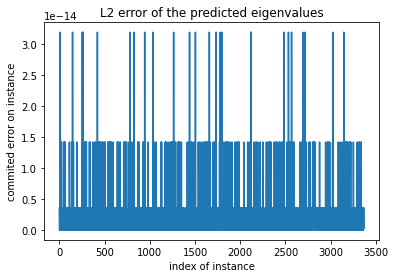

In [16]:
L2_Errors = []
for i in range(predicted_u.shape[0]):
    L2_Errors.append((y_test[i] - predicted_u[i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

In [21]:
T1 = 0
T2 = 5e-20
T3 = 5e-18
T4 = 5e-16
T5 = 5e-14
T6 = 5e-12
T7 = 5e-10
T8 = 5e-8
T9 = 5e-6
T10 = 5e-4
T11 = 5e-2
T12 = 5e-1

S1=S2=S3=S4=S5=S6=S7=S8=S9=S10=S11=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
    elif (item[0]>=T7 and item[0]< T8):
        S7 = S7 + 1
    elif (item[0]>=T8 and item[0]< T9):
        S8 = S8 + 1
    elif (item[0]>=T9 and item[0]< T10):
        S9 = S9 + 1
    elif (item[0]>=T10 and item[0]< T11):
        S10 = S10 + 1
    elif (item[0]>=T11 and item[0]< T12):
        S11 = S11 + 1
print('Percentage of the commited error between 0    ,5e-12 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-12,5e-11 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-11,5e-10 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-10,5e-9  is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-9 ,5e-8  is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-8 ,5e-7  is: %.8f' % ((S6/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-7 ,5e-6  is: %.8f' % ((S7/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6 ,5e-5  is: %.8f' % ((S8/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5 ,5e-4  is: %.8f' % ((S9/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4 ,5e-3 is: %.8f' % ((S10/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3 ,5e-2 is: %.8f' % ((S11/len(L2_Errors)) * 100))

Percentage of the commited error between 0    ,5e-12 is: 44.10454410
Percentage of the commited error between 5e-12,5e-11 is: 2.28690229
Percentage of the commited error between 5e-11,5e-10 is: 9.97920998
Percentage of the commited error between 5e-10,5e-9  is: 43.62934363
Percentage of the commited error between 5e-9 ,5e-8  is: 0.00000000
Percentage of the commited error between 5e-8 ,5e-7  is: 0.00000000
Percentage of the commited error between 5e-7 ,5e-6  is: 0.00000000
Percentage of the commited error between 5e-6 ,5e-5  is: 0.00000000
Percentage of the commited error between 5e-5 ,5e-4  is: 0.00000000
Percentage of the commited error between 5e-4 ,5e-3 is: 0.00000000
Percentage of the commited error between 5e-3 ,5e-2 is: 0.00000000


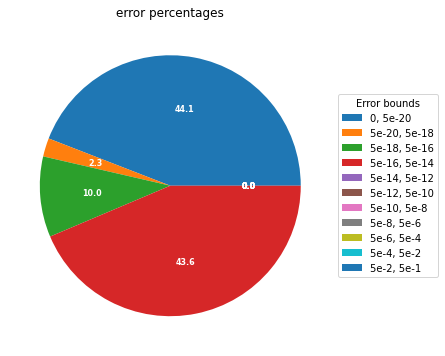

In [24]:

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors)),
          (S7/len(L2_Errors)),
          (S8/len(L2_Errors)),
          (S9/len(L2_Errors)),
          (S10/len(L2_Errors)),
          (S11/len(L2_Errors))]
ingredients = ["0, 5e-20", 
               "5e-20, 5e-18",
               "5e-18, 5e-16",
               "5e-16, 5e-14",
               "5e-14, 5e-12",
               "5e-12, 5e-10",
               "5e-10, 5e-8",
               "5e-8, 5e-6",
               "5e-6, 5e-4",
               "5e-4, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


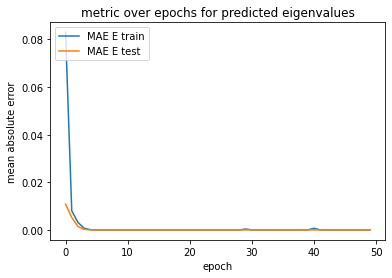

In [19]:
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('metric over epochs for predicted eigenvalues')
plt.ylabel('mean absolute error')
plt.xlabel('epoch')
plt.legend(['MAE E train', 'MAE E test'], loc='upper left')
#plt.show()
plt.savefig('plot1.pdf', bbox_inches='tight')

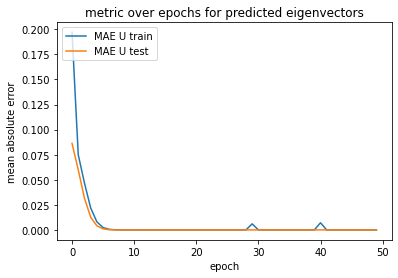

<Figure size 432x288 with 0 Axes>

In [20]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('metric over epochs for predicted eigenvectors')
plt.ylabel('mean absolute error')
plt.xlabel('epoch')
plt.legend(['MAE U train', 'MAE U test'], loc='upper left')
plt.show()
plt.savefig('pl.pdf', bbox_inches='tight')